
# Question Q.1
- Generate a normally distributed dataset using numpy.random.normal().
- Plot a histogram and KDE using seaborn.histplot() or sns.kdeplot().
- Overlay the mean and standard deviation lines on the plot.
- Use scipy.stats.norm.pdf() to show the bell curve (optional).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm 

In [2]:
np.random.seed(42)
data = np.random.normal(loc=50, scale=10,size=1000)


In [3]:
mean = np.mean(data).round(4)
std = np.std(data).round(4)
print("mean : ",mean)
print("Standard Deviation : ",std)

mean :  50.1933
Standard Deviation :  9.7873


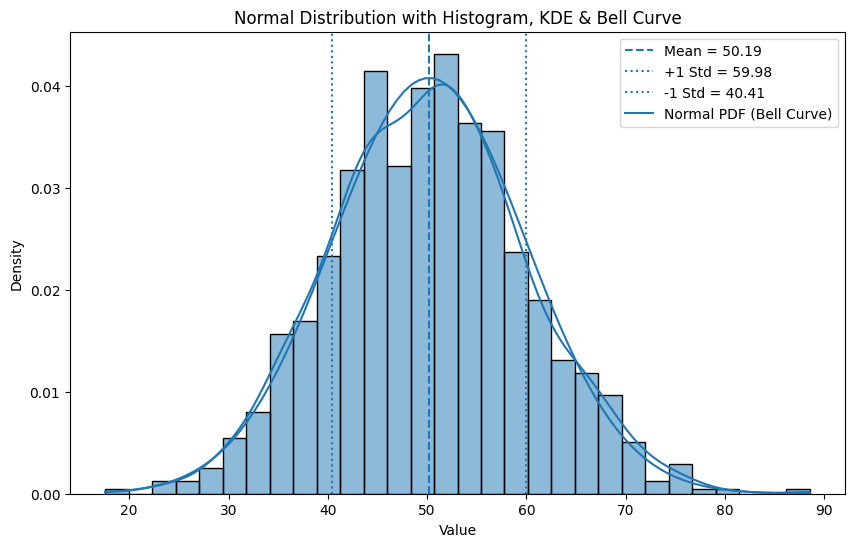

In [4]:
plt.figure(figsize=(10,6)) 
sns.histplot(data,bins=30,kde=True,stat='density')
plt.axvline(mean, linestyle='--', label=f"Mean = {mean:.2f}")
plt.axvline(mean + std, linestyle=':', label=f"+1 Std = {mean+std:.2f}")
plt.axvline(mean - std, linestyle=':', label=f"-1 Std = {mean-std:.2f}")
x = np.linspace(min(data), max(data), 100)
y = norm.pdf(x, mean, std)

plt.plot(x, y, label="Normal PDF (Bell Curve)")
plt.title("Normal Distribution with Histogram, KDE & Bell Curve")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()


# Q : 2
- Load a sample dataset and select a numeric column.
- Calculate using numpy.percentile() or df.quantile():
- 25th percentile
- 50th percentile (median)
- 75th percentile
- Plot these quartiles using vertical lines on a boxplot or histogram.


In [5]:
data = {
    'Marks': [45, 55, 60, 62, 65, 70, 72, 75, 78, 80, 82, 85, 88, 90, 92]
}

df = pd.DataFrame(data)


In [17]:
q1 = np.percentile(df['Marks'], 25)
q2 = np.percentile(df['Marks'], 50)   # Median
q3 = np.percentile(df['Marks'], 75)

print("25th Percentile (Q1):", q1)
print("50th Percentile (Median):", q2)
print("75th Percentile (Q3):", q3)


25th Percentile (Q1): 63.5
50th Percentile (Median): 75.0
75th Percentile (Q3): 83.5


In [18]:
df['Marks'].quantile([0.25, 0.50, 0.75])


0.25    63.5
0.50    75.0
0.75    83.5
Name: Marks, dtype: float64

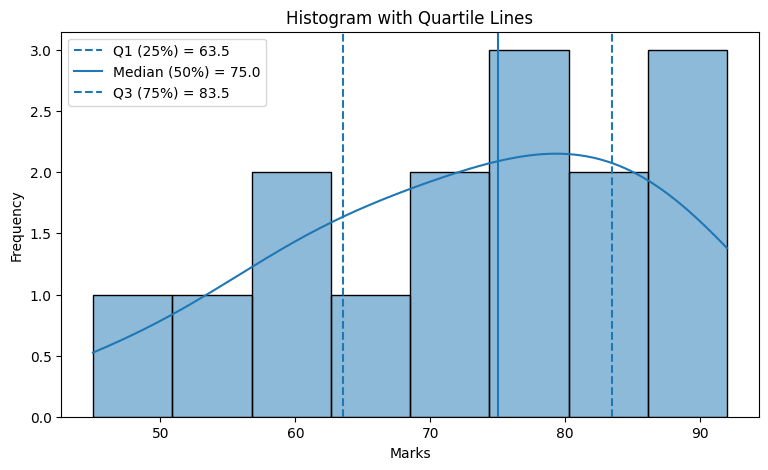

In [8]:
plt.figure(figsize=(9,5))

sns.histplot(df['Marks'], bins=8, kde=True)

plt.axvline(q1, linestyle='--', label=f"Q1 (25%) = {q1}")
plt.axvline(q2, linestyle='-',  label=f"Median (50%) = {q2}")
plt.axvline(q3, linestyle='--', label=f"Q3 (75%) = {q3}")

plt.title("Histogram with Quartile Lines")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# Q : 3
- Print the five-number summary (min, Q1, median, Q3, max) of a column.
- Create a boxplot using seaborn.boxplot() or matplotlib.
- Identify and label outliers from the boxplot.


In [9]:
minimum = df['Marks'].min()
q1 = df['Marks'].quantile(0.25)
median = df['Marks'].quantile(0.50)
q3 = df['Marks'].quantile(0.75)
maximum = df['Marks'].max()

print("Five-Number Summary")
print("Min     :", minimum)
print("Q1      :", q1)
print("Median  :", median)
print("Q3      :", q3)
print("Max     :", maximum)


Five-Number Summary
Min     : 45
Q1      : 63.5
Median  : 75.0
Q3      : 83.5
Max     : 92


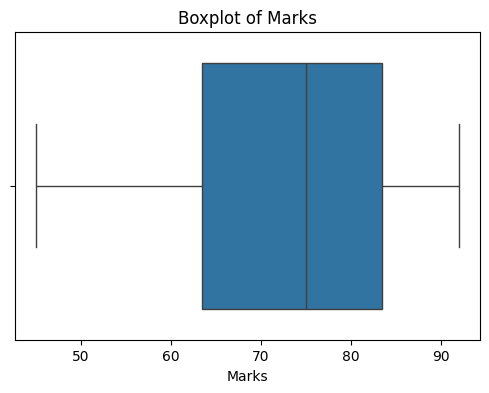

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Marks'])
plt.title("Boxplot of Marks")
plt.show()


In [16]:
IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

outliers = df[(df['Marks'] < lower_bound) | (df['Marks'] > upper_bound)]

print("Outliers:")
print(outliers)


Outliers:
Empty DataFrame
Columns: [Marks]
Index: []


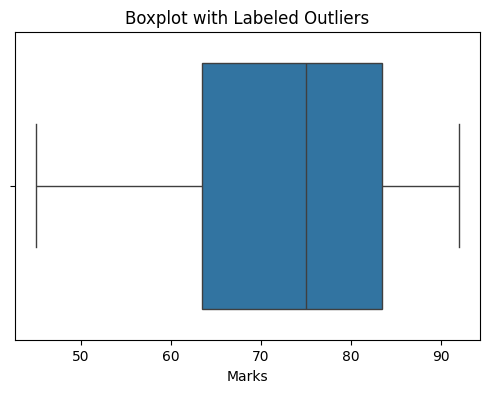

In [12]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Marks'])

for value in outliers['Marks']:
    plt.text(value, 0, f"{value}", color='red', ha='center')

plt.title("Boxplot with Labeled Outliers")
plt.show()


# Q : 4
- Generate 1000 data points from a normal distribution using NumPy.
- Plot a histogram with KDE using Seaborn to visualize the normal distribution.
- Calculate and display the mean and standard deviation of the distribution.
- Generate and compare two normal distributions with different mean and standard deviation.
- Plot the KDEs of both distributions on the same graph for comparison.



In [19]:
np.random.seed(42)
data1 = np.random.normal(loc=50,scale=10,size=1000)


In [25]:
mean1 = np.mean(data1)
std1 = np.std(data1)

print("Distribution 1")
print("Mean:", round(mean1, 2))
print("Standard Deviation:", round(std1, 2))


Distribution 1
Mean: 50.19
Standard Deviation: 9.79


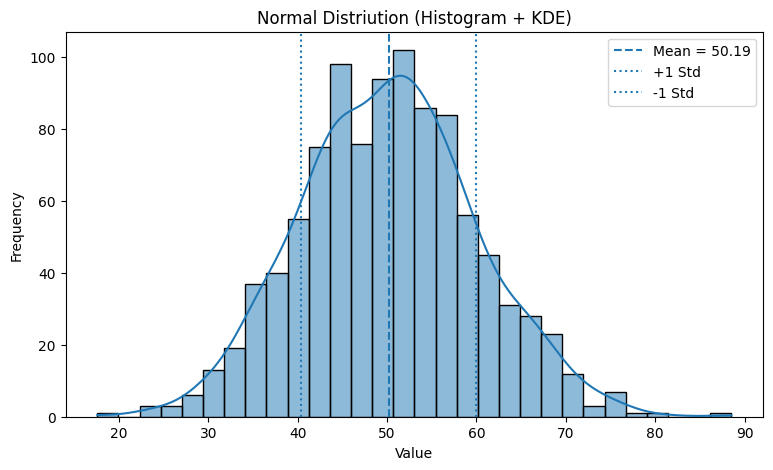

In [32]:
plt.figure(figsize=(9,5))
sns.histplot(data1, bins=30, kde=True)
plt.axvline(mean1, linestyle='--', label=f"Mean = {mean1:.2f}")
plt.axvline(mean1 + std1, linestyle=':', label="+1 Std")
plt.axvline(mean1 - std1, linestyle=':', label="-1 Std")
plt.title("Normal Distriution (Histogram + KDE)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [33]:
data2 = np.random.normal(
    loc=70,     # higher mean
    scale=5,    # smaller spread
    size=1000
)

mean2 = np.mean(data2)
std2 = np.std(data2)

print("\nDistribution 2")
print("Mean:", round(mean2, 2))
print("Standard Deviation:", round(std2, 2))



Distribution 2
Mean: 70.35
Standard Deviation: 4.98


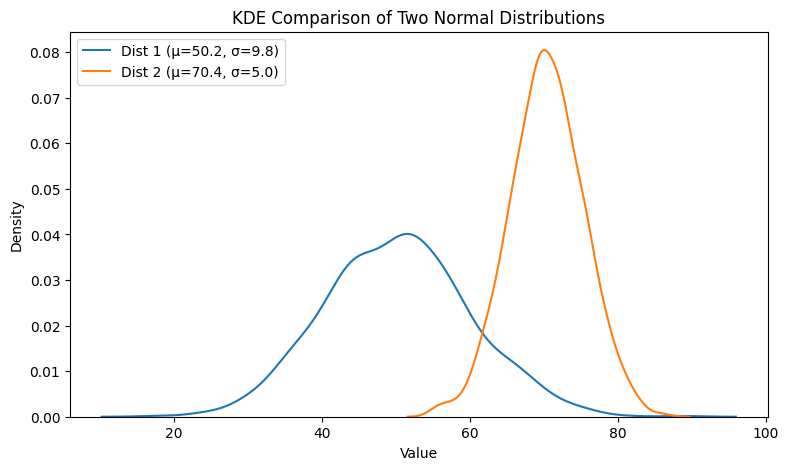

In [34]:
plt.figure(figsize=(9,5))

sns.kdeplot(data1, label=f"Dist 1 (μ={mean1:.1f}, σ={std1:.1f})")
sns.kdeplot(data2, label=f"Dist 2 (μ={mean2:.1f}, σ={std2:.1f})")

plt.title("KDE Comparison of Two Normal Distributions")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()


# Q : 5
- Generate a positively skewed dataset using an exponential distribution.
- Plot the skewed distribution using Seaborn histogram and KDE.
- Calculate and print the skewness value using SciPy or Pandas.
- Interpret whether the dataset is right-skewed, left-skewed, or symmetric based on the skewness value.


In [35]:
np.random.seed(42)

data = np.random.exponential(
    scale=2.0,   # controls spread
    size=1000
)


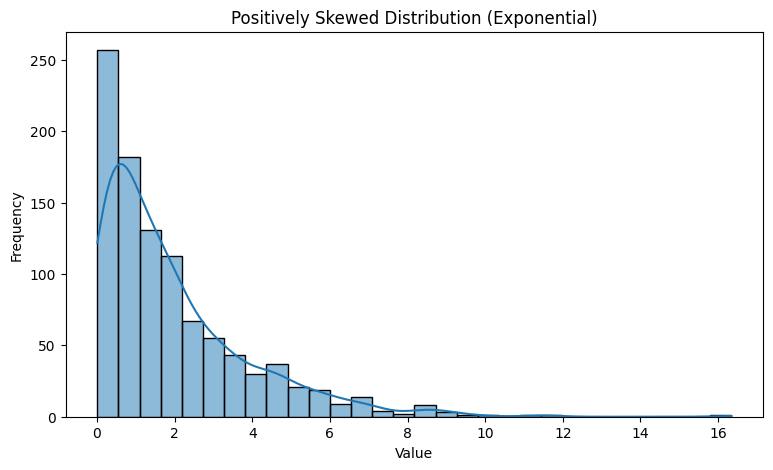

In [36]:
plt.figure(figsize=(9,5))

sns.histplot(data, bins=30, kde=True)

plt.title("Positively Skewed Distribution (Exponential)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [39]:
from scipy.stats import skew
skewness_value = skew(data)
print("Skewness : ",round(skewness_value ,3))

Skewness :  1.865


In [40]:
pd.Series(data).skew()


np.float64(1.8678371468010972)

In [41]:
if skewness_value > 0:
    print("The distribution is right-skewed (positively skewed).")
elif skewness_value < 0:
    print("The distribution is left-skewed (negatively skewed).")
else:
    print("The distribution is symmetric.")


The distribution is right-skewed (positively skewed).


# Q : 6
- Generate two datasets: one with normal distribution and another with a peaked distribution (e.g., Laplace)
- Plot KDE curves of both datasets on the same graph to compare peakedness.
- Calculate and print the kurtosis values of both datasets.
- Interpret the kurtosis values as mesokurtic, leptokurtic, or platykurtic.

In [42]:
# Normal Distribution (Mesokurtic)
np.random.seed(42)

normal_data = np.random.normal(
    loc=0,
    scale=1,
    size=1000
)


In [43]:
# Peaked Distribution – Laplace (Leptokurtic)
laplace_data = np.random.laplace(
    loc=0,
    scale=1,
    size=1000
)


#### 📌 Laplace distribution is more peaked with heavier tails

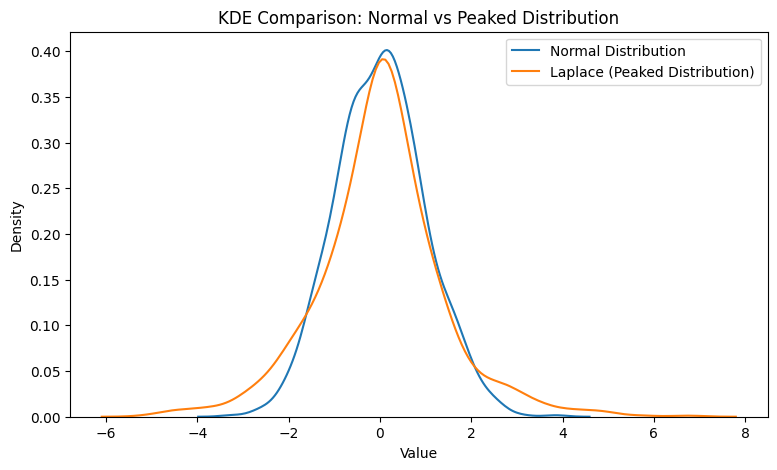

In [44]:
plt.figure(figsize=(9,5))

sns.kdeplot(normal_data, label="Normal Distribution")
sns.kdeplot(laplace_data, label="Laplace (Peaked Distribution)")

plt.title("KDE Comparison: Normal vs Peaked Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()


In [47]:
from scipy.stats import kurtosis
kurt_normal = kurtosis(normal_data)
kurt_laplace = kurtosis(laplace_data)

print("Kurtosis (Normal) : ",round(kurt_normal,3))
print("Kurtosis (Laplace) : ",round(kurt_laplace,3))


Kurtosis (Normal) :  0.066
Kurtosis (Laplace) :  2.095


####  SciPy returns excess kurtosis
##### (Normal distribution ≈ 0)

In [48]:
def interpret_kurtosis(k):
    if k > 0:
        return "Leptokurtic (Peaked & heavy tails)"
    elif k < 0:
        return "Platykurtic (Flat)"
    else:
        return "Mesokurtic (Normal)"

print("Normal Distribution:", interpret_kurtosis(kurt_normal))
print("Laplace Distribution:", interpret_kurtosis(kurt_laplace))


Normal Distribution: Leptokurtic (Peaked & heavy tails)
Laplace Distribution: Leptokurtic (Peaked & heavy tails)
